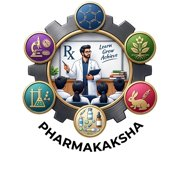

# BP801T · Unit I — AI Lifecycle, Validation and Model Auditing
**Pharmakaksha · Learn · Grow · Achieve**
*Ethical Considerations and Translational Applications of AI in Pharmacy · B.Pharm Semester VIII · PCI NEP 2020*

This notebook contains every example and demo from the Unit I study notes, slides and video, in the same order.

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ajreddys/learn-pharmakaksha-site/blob/main/content/BP801T%20Ethical%20Considerations%20and%20Translational%20Applications%20of%20AI%20in%20Pharmacy%20%28Theory%29/BP801T_Unit1_AI_Lifecycle_and_Validation.ipynb)

**How to use this notebook**
1. Open it at [learn.pharmakaksha.com](https://learn.pharmakaksha.com/notebooks/index.html?path=BP801T%20Ethical%20Considerations%20and%20Translational%20Applications%20of%20AI%20in%20Pharmacy%20%28Theory%29/BP801T_Unit1_AI_Lifecycle_and_Validation.ipynb) (no login needed) or in **Google Colab** with the button above (sign in with Google; use **File → Save a copy in Drive** to keep your work).
2. Click a code cell and press **Shift + Enter** to run it. Run the cells from top to bottom.
3. The practice datasets sit next to this notebook. In Colab they are read from GitHub automatically.

**Using learn.pharmakaksha.com**
Python runs inside your web browser, so nothing is installed and nothing is sent to a server. Use an up-to-date Chrome, Edge, Firefox or Safari, on a laptop or a phone.
- **The first run is slow.** The first time you run a cell, the browser downloads Python, which can take 10–30 seconds. The first `import sklearn` takes a few seconds more. After that, cells run quickly.
- **Check the kernel.** *Python (Pyodide)* appears at the top right. A filled circle means Python is busy, and an empty circle means it is ready.
- **If a cell hangs** or you want a fresh start, use **Kernel → Restart Kernel**, then run the cells from the top again.
- **Save your work.** Press **Ctrl + S** (**Cmd + S** on a Mac). Your work is saved in this browser only. It will not appear on another device, and clearing your browsing data or using a private/incognito window erases it. Use **File → Download** to keep a copy.
- **Start over.** The site keeps opening your saved copy of the notebook. To get the original version back, go to the file list, tick the notebook, click **Delete** and reload the page.

> All datasets are fictional teaching data. The models are for learning only. They are not clinical, regulatory or legal tools.

## 1.1 The AI lifecycle
An AI model is not finished when it is trained. It moves through six stages, and the last one never stops:

**Collect → Preprocess → Model → Validate → Deploy → Monitor** (and back to Collect when the model needs retraining).

In this notebook we follow one fictional hospital project through every stage: **predicting adverse drug reactions (ADRs) at admission**, so that pharmacists can review high-risk patients first.

### Stage 1 — Collect
`adr_ehr.csv` is a fictional extract from an electronic health record (EHR): admissions from 2022 to 2025 at three hospital sites.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

URL = "https://raw.githubusercontent.com/ajreddys/learn-pharmakaksha-site/main/content/BP801T%20Ethical%20Considerations%20and%20Translational%20Applications%20of%20AI%20in%20Pharmacy%20%28Theory%29/"

def load(name):
    """Read a practice CSV from this folder, or from GitHub (Colab)."""
    if os.path.exists(name):
        return pd.read_csv(name)
    return pd.read_csv(URL + name)

TEAL, GREEN, ORANGE, GREY = "#12303A", "#1F8A70", "#E07A2E", "#8A9BA3"
plt.rcParams.update({"figure.figsize": (8, 4.5), "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

ehr = load("adr_ehr.csv")
print(ehr.shape)
ehr.head()

## 1.2 Healthcare data quality (Stage 2 — Preprocess)
Real hospital data is messy. Before any modelling, check the **five common problems**: duplicates, missing values, impossible values, inconsistent coding and wrong units.

In [ ]:
print("Duplicate rows:", ehr.duplicated().sum())
print("\nMissing values per column:")
print(ehr.isna().sum()[ehr.isna().sum() > 0])
print("\nSex codes used:", ehr["sex"].value_counts().to_dict())
print("\nAge range:", ehr["age"].min(), "to", ehr["age"].max())
print("Weight range:", ehr["weight_kg"].min(), "to", ehr["weight_kg"].max())

We find **8 duplicate rows**, **31 missing eGFR values**, **4 different codes for sex**, two ages over 400 (typing errors for 58 and 47) and two weights entered in **grams**. Each fix is written in code, so anyone can repeat it.

In [ ]:
clean = ehr.drop_duplicates().copy()
clean["sex"] = clean["sex"].str.upper().str[0]                       # female/F -> F, m/M -> M
typo = clean["age"] > 120
print("Ages fixed:", clean.loc[typo, "age"].tolist(), end=" -> ")
clean.loc[typo, "age"] = clean.loc[typo, "age"] // 10
print(clean.loc[typo, "age"].tolist())
grams = clean["weight_kg"] > 300
clean.loc[grams, "weight_kg"] = clean.loc[grams, "weight_kg"] / 100   # 6400 -> 64.0 kg
clean["female"] = (clean["sex"] == "F").astype(int)
clean["year"] = clean["admission_date"].str[:4].astype(int)
print("Rows after cleaning:", len(clean))
print("Sex codes now:", clean["sex"].value_counts().to_dict())

Missing eGFR values are **not** filled in here. They are filled inside the model pipeline (section 1.3), using only training data, so that no information leaks from the test set.

**ADR rate by year.** Notice 2025. We will come back to it in section 1.6.

In [ ]:
print(clean.groupby("year")["adr"].agg(["size", "mean"]).round(3))

## 1.3 Training, validation and test sets (Stages 3–4 — Model and Validate)
We build the model on **2022–2024** admissions and keep **2025** aside as "the future".
The 2022–2024 data is split three ways:

| Set | Share | Used for |
|---|---|---|
| Training | 60% | Fitting the model |
| Validation | 20% | Choosing settings (hyperparameters) |
| Test | 20% | One final, honest score — touched once |

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

FEATURES = ["age", "female", "weight_kg", "egfr", "num_drugs",
            "on_anticoagulant", "prior_adr", "liver_disease"]
dev = clean[clean["year"] <= 2024]
future = clean[clean["year"] == 2025]
print("Development:", len(dev), "| 2025 (future):", len(future))

X, y = dev[FEATURES], dev["adr"]
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)
print("Train:", len(X_train), "| Validation:", len(X_val), "| Test:", len(X_test))

A **pipeline** keeps every preprocessing step (fill missing values, scale) inside the model, so the steps are learned from training data only.
We try four values of the regularisation setting `C` and compare them on the **validation** set.

In [ ]:
def make_model(C=1.0):
    return make_pipeline(SimpleImputer(strategy="median"), StandardScaler(),
                         LogisticRegression(C=C, max_iter=1000))

for C in [0.01, 0.1, 1, 10]:
    m = make_model(C).fit(X_train, y_train)
    print(f"C = {C:<5} validation AUC = {roc_auc_score(y_val, m.predict_proba(X_val)[:, 1]):.3f}")

All four values score about 0.76, so the setting hardly matters here. We keep the default `C = 1`.

## 1.4 Cross-validation
One validation split can be lucky or unlucky. **k-fold cross-validation** splits the training data into *k* parts, trains *k* times and validates on each part in turn. The spread of the *k* scores shows how stable the model is.

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(make_model(), X_temp, y_temp, cv=cv, scoring="roc_auc")
print("AUC per fold:", scores.round(3))
print(f"Mean AUC = {scores.mean():.3f} ± {scores.std():.3f}")

Now, and only now, we score the final model **once** on the test set. We also check **calibration**: does the average predicted risk match the real ADR rate?

In [ ]:
from sklearn.metrics import brier_score_loss

model = make_model().fit(X_temp, y_temp)
p_test = model.predict_proba(X_test)[:, 1]
print(f"Test AUC          = {roc_auc_score(y_test, p_test):.3f}")
print(f"Brier score       = {brier_score_loss(y_test, p_test):.3f}   (0 = perfect)")
print(f"Mean predicted ADR = {p_test.mean():.1%}   Observed ADR rate = {y_test.mean():.1%}")

## 1.5 Data leakage
**Leakage** means the model sees information that would not exist at the moment of prediction. Our extract has a column `antidote_given`. An antidote is given **after** an ADR happens, so it cannot be known at admission. Watch what it does to the score.

In [ ]:
LEAKY = FEATURES + ["antidote_given"]
Xl_tr, Xl_te, yl_tr, yl_te = train_test_split(dev[LEAKY], dev["adr"], test_size=0.2, random_state=42, stratify=dev["adr"])
leaky = make_model().fit(Xl_tr, yl_tr)
print(f"With antidote_given:    test AUC = {roc_auc_score(yl_te, leaky.predict_proba(Xl_te)[:, 1]):.3f}")
print(f"Without (honest model): test AUC = {roc_auc_score(y_test, p_test):.3f}")

The leaky model looks excellent (0.92) but is **useless at admission**, because the antidote column is always empty then. A score that looks too good is a warning sign.

Other common leaks: scaling or filling missing values on the **whole** dataset before splitting; the same patient appearing in both training and test sets; and using future dates to predict the past.

## 1.6 Model drift (Stage 6 — Monitor)
After deployment, patients change. In 2025 a new geriatric ward and a new chemotherapy protocol arrived. We score the 2022–2024 model on the 2025 admissions.

In [ ]:
p_future = model.predict_proba(future[FEATURES])[:, 1]
print(f"2025 AUC = {roc_auc_score(future['adr'], p_future):.3f}")
print(f"2025 mean predicted ADR = {p_future.mean():.1%}   observed = {future['adr'].mean():.1%}")

The **ranking** of patients is still good (AUC about 0.77), but the model now **under-predicts** risk: it says 21% while 28% of patients actually had an ADR. This is **drift**.

- **Data drift (covariate shift):** the inputs change, e.g. older patients taking more drugs.
- **Concept drift:** the link between inputs and outcome changes, e.g. a new protocol raises ADR risk for the same patient.

The **Population Stability Index (PSI)** measures how far a feature's distribution has moved. Rule of thumb: below 0.1 stable, 0.1–0.25 moderate shift, above 0.25 major shift.

In [ ]:
def psi(expected, actual, bins=10):
    edges = np.quantile(expected, np.linspace(0, 1, bins + 1))
    edges[0], edges[-1] = -np.inf, np.inf
    e = np.histogram(expected, edges)[0] / len(expected)
    a = np.histogram(actual, edges)[0] / len(actual)
    e, a = np.clip(e, 1e-4, None), np.clip(a, 1e-4, None)
    return float(np.sum((a - e) * np.log(a / e)))

for col in ["age", "num_drugs", "egfr", "weight_kg"]:
    v = psi(dev[col].dropna(), future[col].dropna())
    flag = "major" if v > 0.25 else "moderate" if v > 0.1 else "stable"
    print(f"{col:<10} PSI = {v:.2f}  {flag}")

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
bins = np.arange(0, 14)
ax[0].hist(dev["num_drugs"], bins=bins, density=True, alpha=0.6, color=TEAL, label="2022–24 (training)")
ax[0].hist(future["num_drugs"], bins=bins, density=True, alpha=0.6, color=ORANGE, label="2025")
ax[0].set_xlabel("Number of drugs"); ax[0].set_ylabel("Share of patients"); ax[0].legend()
ax[0].set_title("Data drift: polypharmacy rose")
yrs = clean.groupby("year")["adr"].mean()
pred = [model.predict_proba(clean[clean.year == y][FEATURES])[:, 1].mean() for y in yrs.index]
ax[1].plot(yrs.index, yrs.values * 100, "o-", color=ORANGE, label="Observed ADR %")
ax[1].plot(yrs.index, np.array(pred) * 100, "s--", color=TEAL, label="Model's predicted %")
ax[1].set_xticks(yrs.index); ax[1].set_ylabel("ADR rate (%)"); ax[1].legend()
ax[1].set_title("Calibration drift in 2025")
plt.tight_layout(); plt.show()

**What to do about drift:** monitor inputs and outcomes on a schedule, set alert thresholds (e.g. PSI > 0.25, or a gap of more than 5 percentage points between predicted and observed rates), then **recalibrate or retrain** under change control and document the new version.

## 1.7 Documentation and reproducibility
A result that cannot be repeated cannot be trusted or audited. Three habits make work reproducible:
1. **Fix random seeds** (`random_state=42`) so splits and models come out the same every time.
2. **Record versions** of Python and libraries.
3. **Fingerprint the data** with a hash, so you can prove which file the model was trained on.

In [ ]:
import sys, hashlib, sklearn

data_bytes = clean.to_csv(index=False).encode()
fingerprint = hashlib.sha256(data_bytes).hexdigest()[:16]
print("Python      :", sys.version.split()[0])
print("scikit-learn:", sklearn.__version__)
print("pandas      :", pd.__version__)
print("Data SHA-256 (first 16 characters):", fingerprint)

A **model card** is a one-page summary of a model: what it is for, what data it learned from, how well it works, for whom it works less well, and when it must not be used.

In [ ]:
model_card = {
    "Model": "ADR risk at admission v1.0 (logistic regression)",
    "Intended use": "Rank admitted adults for pharmacist medication review. Decision support only.",
    "Not for": "Children, outpatients, or as the only basis for stopping a drug",
    "Training data": f"Hospital EHR 2022–2024, {len(dev)} admissions, 3 sites, data hash {fingerprint}",
    "Features": ", ".join(FEATURES),
    "Performance": f"Test AUC {roc_auc_score(y_test, p_test):.2f}; 5-fold CV AUC {scores.mean():.2f} ± {scores.std():.2f}",
    "Known limits": "Under-predicts in 2025 (drift); see subgroup audit",
    "Owner / review": "Clinical pharmacy AI committee; re-validate every 6 months",
}
for k, v in model_card.items():
    print(f"{k:<15}: {v}")

## 1.8 Model auditing basics
An **audit** asks: does the model work equally well for **every group** of patients? We use 5-fold cross-validated predictions for all 1,125 development patients, so each patient is scored by a model that never saw them. A patient is flagged when predicted risk ≥ 20%.

In [ ]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import recall_score, precision_score

audit = dev.copy()
audit["risk"] = cross_val_predict(make_model(), X, y, cv=cv, method="predict_proba")[:, 1]
audit["flag"] = (audit["risk"] >= 0.20).astype(int)
audit["age_group"] = pd.cut(audit["age"], [0, 40, 65, 200], labels=["18–39", "40–64", "65+"], right=False)
audit["group"] = np.where(audit["female"] == 1,
                          np.where(audit["weight_kg"] < 50, "Women < 50 kg", "Women ≥ 50 kg"), "Men")

def report(df, by):
    rows = []
    for g, s in df.groupby(by, observed=True):
        rows.append({by: g, "n": len(s), "observed ADR %": round(100 * s["adr"].mean(), 1),
                     "predicted %": round(100 * s["risk"].mean(), 1),
                     "sensitivity": round(recall_score(s["adr"], s["flag"]), 2),
                     "AUC": round(roc_auc_score(s["adr"], s["risk"]), 2)})
    return pd.DataFrame(rows)

print(report(audit, "group").to_string(index=False))
print()
print(report(audit, "age_group").to_string(index=False))

**Audit findings**
- **Women under 50 kg:** 35.7% had an ADR, but the model predicted only 24%. The model under-estimates their risk, because low body weight raises risk more in women than the simple model can capture, and women are only a third of the data.
- **Age 18–39:** sensitivity is 0 at the 20% threshold. Their ADRs are rare (4%), so the model never flags them. A rule-based check may be needed for young patients on high-risk drugs.
- **Action:** report these limits in the model card, add a weight × sex term or a separate check, and re-audit.

## Quick check
A model scores AUC 0.99 on the test set. The feature list includes `discharge_diagnosis`. What has gone wrong? Decide, then run the cell.

In [ ]:
print("Data leakage: the discharge diagnosis is written after the outcome, so it is not available at prediction time.")

## Try it yourself (lab)
Write your code in the empty cells. Solutions are at the end of the notebook.

**1.** In the raw `ehr` table, how many patients have a missing eGFR at each site (A, B, C)?

**2.** Run 10-fold cross-validation (`n_splits=10`) for `make_model()` on `X_temp, y_temp`. Report the mean and standard deviation of the AUC. Is it close to the 5-fold result?

**3.** Compute the PSI of `on_anticoagulant` between `dev` and `future` using 2 bins. Hint: compare the share of patients on anticoagulants in each period first.

**4.** Repeat the subgroup audit by `site`. Does any site stand out?

---
## Solutions

In [ ]:
# 1
print(ehr[ehr["egfr"].isna()].groupby("site").size())

In [ ]:
# 2
cv10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
s10 = cross_val_score(make_model(), X_temp, y_temp, cv=cv10, scoring="roc_auc")
print(f"10-fold AUC = {s10.mean():.3f} ± {s10.std():.3f}")   # similar mean, wider spread (smaller folds)

In [ ]:
# 3
print("Share on anticoagulants:", round(dev["on_anticoagulant"].mean(), 3), "->", round(future["on_anticoagulant"].mean(), 3))
e = dev["on_anticoagulant"].value_counts(normalize=True).sort_index().values
a = future["on_anticoagulant"].value_counts(normalize=True).sort_index().values
print("PSI =", round(float(np.sum((a - e) * np.log(a / e))), 3))   # small: below 0.1

In [ ]:
# 4
print(report(audit, "site").to_string(index=False))   # all three sites perform similarly

---
**Next:** Unit II — Regulatory Framework and Explainable AI. Pharmakaksha · Learn · Grow · Achieve